# Set Up

In [1]:
import json
import math
import time
import os
import numpy as np
import subprocess

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as sql_f
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, RobustScaler, StandardScaler, Imputer
from pyspark.ml.classification import GBTClassifier, RandomForestClassifier, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

from pyspark.mllib.evaluation import MulticlassMetrics

In [2]:
spark = (
    SparkSession.builder
    .appName("SO2_Classification_M3")
    # Optimise for large Parquet reads on GCS
    .config("spark.sql.parquet.enableVectorizedReader", "true")
    .config("spark.sql.shuffle.partitions", "400")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

26/04/30 19:19:37 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [3]:
# Set the path
data_path = "gs://st446-m2-outputs/features/pilot_june2023_5day_wind_corrected.parquet"
new_data_path = "gs://st446-m2-outputs/features/pilot_june2023_1_5day_nowindcorrection.parquet"
output_path = "gs://st446-a2-ml/" 

In [4]:
# Load the datasets
raw_df = spark.read.parquet(data_path)
new_raw_df = spark.read.parquet(new_data_path)

In [5]:
# Preview the data structure
raw_df.printSchema()
raw_df.describe().show()
raw_df.groupBy("label").count().orderBy("label").show()

root
 |-- nearest_source_name: string (nullable = true)
 |-- so2_no2_ratio: double (nullable = true)
 |-- vcd_height_ratio: double (nullable = true)
 |-- aerosol_index: float (nullable = true)
 |-- wind_corrected_dist_km: float (nullable = true)
 |-- raw_dist_km: double (nullable = true)
 |-- source_elevation_m: integer (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- wind_x_ratio: double (nullable = true)
 |-- cloud_fraction: float (nullable = true)
 |-- solar_zenith_angle: float (nullable = true)
 |-- sensor_zenith_angle: float (nullable = true)
 |-- surface_altitude: float (nullable = true)
 |-- month: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- label: integer (nullable = true)



26/04/30 19:19:46 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-------------------+--------------------+-------------------+--------------------+----------------------+------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+------------------+--------+-----------------+-------------------+
|summary|nearest_source_name|       so2_no2_ratio|   vcd_height_ratio|       aerosol_index|wind_corrected_dist_km|       raw_dist_km|source_elevation_m|         wind_speed|        wind_x_ratio|      cloud_fraction|solar_zenith_angle|sensor_zenith_angle|  surface_altitude|   month|      hour_of_day|              label|
+-------+-------------------+--------------------+-------------------+--------------------+----------------------+------------------+------------------+-------------------+--------------------+--------------------+------------------+-------------------+------------------+--------+-----------------+-------------------+
|  count|           13636827|           

+-----+--------+
|label|   count|
+-----+--------+
|    0|12105570|
|    1| 1531257|
+-----+--------+



In [6]:
new_raw_df.printSchema()
new_raw_df.describe().show()
new_raw_df.groupBy("label").count().orderBy("label").show()

root
 |-- nearest_source_name: string (nullable = true)
 |-- so2_no2_ratio: double (nullable = true)
 |-- vcd_height_ratio: double (nullable = true)
 |-- aerosol_index: float (nullable = true)
 |-- raw_pixel_dist_km: float (nullable = true)
 |-- raw_dist_km: double (nullable = true)
 |-- source_elevation_m: integer (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- wind_x_ratio: double (nullable = true)
 |-- cloud_fraction: float (nullable = true)
 |-- solar_zenith_angle: float (nullable = true)
 |-- sensor_zenith_angle: float (nullable = true)
 |-- surface_altitude: float (nullable = true)
 |-- month: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- label: integer (nullable = true)



+-------+-------------------+--------------------+-------------------+--------------------+------------------+------------------+------------------+-------------------+--------------------+-------------------+------------------+-------------------+------------------+--------+-----------------+-------------------+
|summary|nearest_source_name|       so2_no2_ratio|   vcd_height_ratio|       aerosol_index| raw_pixel_dist_km|       raw_dist_km|source_elevation_m|         wind_speed|        wind_x_ratio|     cloud_fraction|solar_zenith_angle|sensor_zenith_angle|  surface_altitude|   month|      hour_of_day|              label|
+-------+-------------------+--------------------+-------------------+--------------------+------------------+------------------+------------------+-------------------+--------------------+-------------------+------------------+-------------------+------------------+--------+-----------------+-------------------+
|  count|           12708842|            12708842|     

+-----+--------+
|label|   count|
+-----+--------+
|    0|11209393|
|    1| 1499449|
+-----+--------+



# Preprocessing

In [7]:
# Cast all columns to double
float_cols = [
    "aerosol_index", "wind_corrected_dist_km", "cloud_fraction",
    "solar_zenith_angle", "sensor_zenith_angle", "surface_altitude",
]
# Drop the column of month as it is a dataset only includes June
int_cols = ["source_elevation_m", "label", "hour_of_day"]
df = raw_df.drop("month")

for c in float_cols + int_cols:
    df = df.withColumn(c, sql_f.col(c).cast(DoubleType()))
    
# Cyclic encoding of hour_of_day
df = (
    df
    .withColumn("hour_sin", sql_f.sin(sql_f.col("hour_of_day") * 2 * math.pi / 24))
    .withColumn("hour_cos", sql_f.cos(sql_f.col("hour_of_day") * 2 * math.pi / 24))
    .drop("hour_of_day")
)

In [8]:
float_cols_new = [
    "aerosol_index", "raw_pixel_dist_km", "cloud_fraction",
    "solar_zenith_angle", "sensor_zenith_angle", "surface_altitude",
]
int_cols_new = ["source_elevation_m", "label", "hour_of_day"]

df_new = new_raw_df.drop("month")
for c in float_cols_new + int_cols_new:
    df_new = df_new.withColumn(c, sql_f.col(c).cast(DoubleType()))

df_new = (
    df_new
    .withColumn("hour_sin", sql_f.sin(sql_f.col("hour_of_day") * 2 * math.pi / 24))
    .withColumn("hour_cos", sql_f.cos(sql_f.col("hour_of_day") * 2 * math.pi / 24))
    .drop("hour_of_day")
)

In [9]:
quantiles = df.approxQuantile(
    ["so2_no2_ratio", "wind_x_ratio", "raw_dist_km"],
    [0.01, 0.25, 0.50, 0.75, 0.99],
    0.001  # relative error
)
for col, q in zip(["so2_no2_ratio", "wind_x_ratio", "raw_dist_km"], quantiles):
    print(f"{col}: 1%={q[0]:.4f}, Q1={q[1]:.4f}, median={q[2]:.4f}, Q3={q[3]:.4f}, 99%={q[4]:.4f}")

so2_no2_ratio: 1%=-370.7333, Q1=-11.0662, median=2.5398, Q3=17.8090, 99%=380.5027
wind_x_ratio: 1%=-2007.8559, Q1=-46.0287, median=7.9997, Q3=77.5144, 99%=2103.3431
raw_dist_km: 1%=43.1422, Q1=242.0125, median=389.5276, Q3=601.8720, 99%=1405.7901


In [10]:
# Compute quantiles for the new dataset
quantiles_new = df_new.approxQuantile(
    ["so2_no2_ratio", "wind_x_ratio", "raw_pixel_dist_km"],
    [0.01, 0.99], 0.001
)
clip_bounds_new = {
    "so2_no2_ratio":    (quantiles_new[0][0], quantiles_new[0][1]),
    "wind_x_ratio":     (quantiles_new[1][0], quantiles_new[1][1]),
    "raw_pixel_dist_km":(quantiles_new[2][0], quantiles_new[2][1]),
}
for col_name, (lo, hi) in clip_bounds_new.items():
    df_new = df_new.withColumn(
        col_name,
        sql_f.least(sql_f.greatest(sql_f.col(col_name), sql_f.lit(lo)), sql_f.lit(hi))
    )
df_new = df_new.withColumn("raw_dist_km", sql_f.log1p(sql_f.col("raw_dist_km")))

In [11]:
# Process the extreme-outlier columns
clip_bounds = {
    "so2_no2_ratio": (-376.52,  373.76),
    "wind_x_ratio":  (-1967.43, 2141.78),
    "raw_dist_km":   (43.05,    1407.26), 
}

for col_name, (lo, hi) in clip_bounds.items():
    df = df.withColumn(
        col_name,
        sql_f.least(sql_f.greatest(sql_f.col(col_name), sql_f.lit(lo)), sql_f.lit(hi))
    )

In [12]:
df = df.withColumn("raw_dist_km", sql_f.log1p(sql_f.col("raw_dist_km")))

In [13]:
# Replace the missing value with median
imputer = Imputer(
    inputCols=["aerosol_index"],
    outputCols=["aerosol_index"],
    strategy="median",
)

# Model Training
## Train and test spliting

In [14]:
train_v, test_v = df.filter(sql_f.col("label") == 1).randomSplit([0.8, 0.2], seed=42)
train_i, test_i = df.filter(sql_f.col("label") == 0).randomSplit([0.8, 0.2], seed=42)
train_df = train_v.union(train_i)
test_df = test_v.union(test_i)
train_df.cache()
test_df.cache()

DataFrame[nearest_source_name: string, so2_no2_ratio: double, vcd_height_ratio: double, aerosol_index: double, wind_corrected_dist_km: double, raw_dist_km: double, source_elevation_m: double, wind_speed: double, wind_x_ratio: double, cloud_fraction: double, solar_zenith_angle: double, sensor_zenith_angle: double, surface_altitude: double, label: double, hour_sin: double, hour_cos: double]

In [15]:
# Split the data accoring to the source
def source_level_split(df, seed=42):
    volcanic_src   = df.filter(sql_f.col("label") == 1) \
                       .select("nearest_source_name").distinct()
    industrial_src = df.filter(sql_f.col("label") == 0) \
                       .select("nearest_source_name").distinct()

    v_train_src, v_test_src = volcanic_src.randomSplit([0.8, 0.2], seed=seed)
    i_train_src, i_test_src = industrial_src.randomSplit([0.8, 0.2], seed=seed)

    train_src = v_train_src.union(i_train_src)
    test_src  = v_test_src.union(i_test_src)

    train_df = df.join(train_src, "nearest_source_name").drop("nearest_source_name")
    test_df  = df.join(test_src,  "nearest_source_name").drop("nearest_source_name")

    # Recompute class weights on training set only
    total = train_df.count()
    n_volcanic = train_df.filter(sql_f.col("label") == 1).count()
    n_indust   = train_df.filter(sql_f.col("label") == 0).count()
    w_volcanic = total / (2 * n_volcanic)
    w_indust   = total / (2 * n_indust)

    train_df = train_df.withColumn(
        "class_weight",
        sql_f.when(sql_f.col("label") == 1, w_volcanic).otherwise(w_indust)
    )
    test_df = test_df.withColumn(
        "class_weight",
        sql_f.when(sql_f.col("label") == 1, w_volcanic).otherwise(w_indust)
    )
    print(f"class weights → volcanic: {w_volcanic:.4f}, industrial: {w_indust:.4f}")
    return train_df, test_df

In [16]:
train_df, test_df= source_level_split(df)
train_df_new, test_df_new = source_level_split(df_new)

class weights → volcanic: 4.7239, industrial: 0.5592


class weights → volcanic: 4.1319, industrial: 0.5688


In [17]:
all_features = [
    "so2_no2_ratio",
    "vcd_height_ratio",
    "aerosol_index",
    "wind_corrected_dist_km",
    "raw_dist_km",
    "wind_speed",
    "wind_x_ratio",
    "cloud_fraction",
    "solar_zenith_angle",
    "sensor_zenith_angle",
    "surface_altitude",
    "hour_sin",
    "hour_cos",
]
# raw_pixel_dist_km replaces wind_corrected_dist_km in the feature list
all_features_new = [
    "so2_no2_ratio", "vcd_height_ratio", "aerosol_index",
    "raw_pixel_dist_km", "raw_dist_km", 
    "wind_speed", "wind_x_ratio", "cloud_fraction",
    "solar_zenith_angle", "sensor_zenith_angle", "surface_altitude",
    "hour_sin", "hour_cos",
]

features_to_robust_scale = [
    "so2_no2_ratio",
    "wind_x_ratio",
    "aerosol_index",
    "surface_altitude",
    "wind_corrected_dist_km",
]

features_to_std_scale = [
    "vcd_height_ratio",
    "wind_speed",
    "cloud_fraction",
    "solar_zenith_angle",
    "sensor_zenith_angle",
    "raw_dist_km",
    "hour_sin",
    "hour_cos",
]

In [18]:
# Handle the missing value for new dataset
assembler_new = VectorAssembler(
    inputCols=all_features_new, outputCol="features", handleInvalid="skip"
)
imputer_new = Imputer(
    inputCols=["aerosol_index"], outputCols=["aerosol_index"], strategy="median"
)

## Build the pipeline

In [19]:
def make_tree_pipeline(classifier, feature_cols):
    """
    GBT and RF: impute → assemble → classify.
    no scaling needed — decision tree splits are
    invariant to monotonic feature transforms.
    """
    imputer_stage = Imputer(
        inputCols=["aerosol_index"],
        outputCols=["aerosol_index"],
        strategy="median",
    )
    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="features",
        handleInvalid="skip",
    )
    return Pipeline(stages=[imputer_stage, assembler, classifier])


def make_lr_pipeline(classifier):
    """
    Logistic Regression: impute → robust scale heavy-tailed
    columns → standard scale well-behaved columns →
    assemble final feature vector → classify.
    """
    imputer_stage = Imputer(
        inputCols=["aerosol_index"],
        outputCols=["aerosol_index"],
        strategy="median",
    )

    # assemble robust-scale columns
    asm_robust = VectorAssembler(
        inputCols=features_to_robust_scale,
        outputCol="vec_robust_raw",
        handleInvalid="skip",
    )
    robust_scaler = RobustScaler(
        inputCol="vec_robust_raw",
        outputCol="vec_robust_scaled",
        withScaling=True,
        withCentering=True,
    )

    # assemble std-scale columns
    asm_std = VectorAssembler(
        inputCols=features_to_std_scale,
        outputCol="vec_std_raw",
        handleInvalid="skip",
    )
    std_scaler = StandardScaler(
        inputCol="vec_std_raw",
        outputCol="vec_std_scaled",
        withMean=True,
        withStd=True,
    )

    # combine both scaled vectors into final features
    asm_final = VectorAssembler(
        inputCols=["vec_robust_scaled", "vec_std_scaled"],
        outputCol="features",
        handleInvalid="skip",
    )

    return Pipeline(stages=[
        imputer_stage,
        asm_robust, robust_scaler,
        asm_std,    std_scaler,
        asm_final,
        classifier,
    ])

In [20]:
gbt_model = GBTClassifier(
    labelCol="label", featuresCol="features", weightCol="class_weight",
    maxIter=100, maxDepth=5, stepSize=0.1, subsamplingRate=0.8, seed=42,
)
rf_model = RandomForestClassifier(
    labelCol="label", featuresCol="features", weightCol="class_weight",
    numTrees=100, maxDepth=10, seed=42,
)
lr_model = LogisticRegression(
    labelCol="label", featuresCol="features", weightCol="class_weight",
    maxIter=100, regParam=0.01, elasticNetParam=0.0, family="binomial",
)

# Raw-labels models
gbt_new = GBTClassifier(
    labelCol="label", featuresCol="features", weightCol="class_weight",
    maxIter=100, maxDepth=5, stepSize=0.1, subsamplingRate=0.8, seed=42,
)
rf_new = RandomForestClassifier(
    labelCol="label", featuresCol="features", weightCol="class_weight",
    numTrees=100, maxDepth=10, seed=42,
)

pipeline_gbt     = make_tree_pipeline(gbt_model, all_features)
pipeline_rf      = make_tree_pipeline(rf_model, all_features)
pipeline_lr      = make_lr_pipeline(lr_model)
pipeline_gbt_new = make_tree_pipeline(gbt_new, all_features_new)
pipeline_rf_new  = make_tree_pipeline(rf_new, all_features_new)

## Fitting

In [21]:
# Wind-corrected dataset
t0 = time.time()
fitted_gbt = pipeline_gbt.fit(train_df)
gbt_time = time.time() - t0
preds_gbt = fitted_gbt.transform(test_df)
preds_gbt.cache()

fi_gbt = fitted_gbt.stages[-1].featureImportances
fi_gbt_dict = {all_features[i]: float(fi_gbt[i]) for i in range(len(all_features))}

t0 = time.time()
fitted_rf = pipeline_rf.fit(train_df)
rf_time = time.time() - t0
preds_rf = fitted_rf.transform(test_df)
preds_rf.cache()

fi_rf = fitted_rf.stages[-1].featureImportances
fi_rf_dict = {all_features[i]: float(fi_rf[i]) for i in range(len(all_features))}

t0 = time.time()
fitted_lr = pipeline_lr.fit(train_df)
lr_time = time.time() - t0
preds_lr = fitted_lr.transform(test_df)
preds_lr.cache()

26/04/30 19:37:39 WARN DAGScheduler: Broadcasting large task binary with size 1013.2 KiB
26/04/30 19:38:29 WARN DAGScheduler: Broadcasting large task binary with size 1861.4 KiB
26/04/30 19:39:23 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB
26/04/30 19:40:20 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
26/04/30 19:41:20 WARN DAGScheduler: Broadcasting large task binary with size 1677.0 KiB
26/04/30 19:41:21 WARN DAGScheduler: Broadcasting large task binary with size 11.1 MiB
26/04/30 19:42:24 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB


DataFrame[so2_no2_ratio: double, vcd_height_ratio: double, aerosol_index: double, wind_corrected_dist_km: double, raw_dist_km: double, source_elevation_m: double, wind_speed: double, wind_x_ratio: double, cloud_fraction: double, solar_zenith_angle: double, sensor_zenith_angle: double, surface_altitude: double, label: double, hour_sin: double, hour_cos: double, class_weight: double, vec_robust_raw: vector, vec_robust_scaled: vector, vec_std_raw: vector, vec_std_scaled: vector, features: vector, rawPrediction: vector, probability: vector, prediction: double]

In [22]:
# Raw-labels dataset
t0 = time.time()
fitted_gbt_new = pipeline_gbt_new.fit(train_df_new)
gbt_new_time = time.time() - t0
preds_gbt_new = fitted_gbt_new.transform(test_df_new)
preds_gbt_new.cache()

t0 = time.time()
fitted_rf_new = pipeline_rf_new.fit(train_df_new)
rf_new_time = time.time() - t0
preds_rf_new = fitted_rf_new.transform(test_df_new)
preds_rf_new.cache()

26/04/30 19:58:41 WARN DAGScheduler: Broadcasting large task binary with size 1001.9 KiB
26/04/30 19:59:27 WARN DAGScheduler: Broadcasting large task binary with size 1817.5 KiB
26/04/30 20:00:26 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/04/30 20:01:25 WARN DAGScheduler: Broadcasting large task binary with size 5.9 MiB
26/04/30 20:02:22 WARN DAGScheduler: Broadcasting large task binary with size 1549.8 KiB
26/04/30 20:02:23 WARN DAGScheduler: Broadcasting large task binary with size 10.4 MiB
26/04/30 20:03:22 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB


DataFrame[so2_no2_ratio: double, vcd_height_ratio: double, aerosol_index: double, raw_pixel_dist_km: double, raw_dist_km: double, source_elevation_m: double, wind_speed: double, wind_x_ratio: double, cloud_fraction: double, solar_zenith_angle: double, sensor_zenith_angle: double, surface_altitude: double, label: double, hour_sin: double, hour_cos: double, class_weight: double, features: vector, rawPrediction: vector, probability: vector, prediction: double]

In [23]:
fi_gbt_new = fitted_gbt_new.stages[-1].featureImportances
fi_gbt_new_dict = {
    all_features_new[i]: float(fi_gbt_new[i])
    for i in range(len(all_features_new))
}

fi_rf_new = fitted_rf_new.stages[-1].featureImportances
fi_rf_new_dict = {
    all_features_new[i]: float(fi_rf_new[i])
    for i in range(len(all_features_new))
}

In [24]:
train_times = {
    "gbt":                    gbt_time,
    "random_forest":          rf_time,
    "logistic_regression":    lr_time,
    "gbt_raw_labels":      gbt_new_time,
    "rf_raw_labels":       rf_new_time  
}
for model, t in train_times.items():
    print(f"{model:<32} {t:>6.1f}s")

gbt                               598.7s
random_forest                     586.8s
logistic_regression               137.5s
gbt_raw_labels                    583.3s
rf_raw_labels                     523.8s


# Evaluation and Visualisation

## Evaluation

In [25]:
# Evaluators
eval_auc    = BinaryClassificationEvaluator(
                  labelCol="label", metricName="areaUnderROC")
eval_pr     = BinaryClassificationEvaluator(
                  labelCol="label", metricName="areaUnderPR")
eval_acc    = MulticlassClassificationEvaluator(
                  labelCol="label", predictionCol="prediction",
                  metricName="accuracy")
eval_f1     = MulticlassClassificationEvaluator(
                  labelCol="label", predictionCol="prediction",
                  metricName="f1")
eval_prec   = MulticlassClassificationEvaluator(
                  labelCol="label", predictionCol="prediction",
                  metricName="weightedPrecision")
eval_recall = MulticlassClassificationEvaluator(
                  labelCol="label", predictionCol="prediction",
                  metricName="weightedRecall")

In [26]:
# Confusion matrix counts
def get_confusion_matrix(preds_df):
    pairs_rdd = (
        preds_df
        .select(
            sql_f.col("prediction").cast(DoubleType()),
            sql_f.col("label").cast(DoubleType())
        )
        .rdd
        .map(lambda row: (row[0], row[1]))
        .coalesce(20)
    )
    mm = MulticlassMetrics(pairs_rdd)
    cm = mm.confusionMatrix().toArray()
    return {
        "tn": int(cm[0][0]), "fp": int(cm[0][1]),
        "fn": int(cm[1][0]), "tp": int(cm[1][1]),
    }

In [27]:
# Evaluation for all models
def evaluate(preds_df, model_name, train_time=0.0):
    result = {"model": model_name, "train_time_s": train_time}
 
    result["auc_roc"]   = eval_auc.evaluate(preds_df)
    result["auc_pr"]    = eval_pr.evaluate(preds_df)
    result["accuracy"]  = eval_acc.evaluate(preds_df)
    result["f1"]        = eval_f1.evaluate(preds_df)
    result["precision"] = eval_prec.evaluate(preds_df)
    result["recall"]    = eval_recall.evaluate(preds_df)
 
    cm = get_confusion_matrix(preds_df)
    result.update(cm)
 
    tn, fp, fn, tp = cm["tn"], cm["fp"], cm["fn"], cm["tp"]
 
    result["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
 
    denom = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) ** 0.5
    result["mcc"] = (tp*tn - fp*fn) / denom if denom > 0 else 0.0
 
    return result

In [28]:
preds_gbt.unpersist()
preds_rf.unpersist()
preds_lr.unpersist()

train_df.unpersist()
test_df.unpersist()

DataFrame[so2_no2_ratio: double, vcd_height_ratio: double, aerosol_index: double, wind_corrected_dist_km: double, raw_dist_km: double, source_elevation_m: double, wind_speed: double, wind_x_ratio: double, cloud_fraction: double, solar_zenith_angle: double, sensor_zenith_angle: double, surface_altitude: double, label: double, hour_sin: double, hour_cos: double, class_weight: double]

In [29]:
res_gbt = evaluate(preds_gbt, "gbt", train_times["gbt"])
res_rf  = evaluate(preds_rf,  "random_forest", train_times["random_forest"])
res_lr  = evaluate(preds_lr,  "logistic_regression", train_times["logistic_regression"])
res_gbt_new = evaluate(preds_gbt_new, "gbt_raw_labels", gbt_new_time)
res_rf_new  = evaluate(preds_rf_new,  "rf_raw_labels", rf_new_time)

all_results = [res_gbt, res_rf, res_lr, res_gbt_new, res_rf_new]

/usr/lib/spark/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
26/04/30 20:12:58 WARN DAGScheduler: Broadcasting large task binary with size 7.6 MiB
26/04/30 20:13:33 WARN DAGScheduler: Broadcasting large task binary with size 7.6 MiB
26/04/30 20:14:01 WARN DAGScheduler: Broadcasting large task binary with size 7.6 MiB
26/04/30 20:14:28 WARN DAGScheduler: Broadcasting large task binary with size 7.6 MiB
26/04/30 20:14:55 WARN DAGScheduler: Broadcasting large task binary with size 7.6 MiB
26/04/30 20:15:21 WARN DAGScheduler: Broadcasting large task binary with size 7.6 MiB
26/04/30 20:15:47 WARN DAGScheduler: Broadcasting large task binary with size 7.5 MiB
26/04/30 20:15:47 WARN DAGScheduler: Broadcasting large task binary with size 7.5 MiB
26/04/30 20:18:55 WARN DAGScheduler: Broadcasting large task binary with size 7.1 MiB
26/04/30 20:19:10 WARN DAGScheduler: Broadcasting large task binary with si

In [30]:
results_json = json.dumps({
    "metrics":         all_results,
    "fi_gbt":          fi_gbt_dict,
    "fi_rf":           fi_rf_dict,
    "fi_gbt_new":      fi_gbt_new_dict,
    "fi_rf_new":       fi_rf_new_dict,
    "train_times":     train_times,
}, indent=2, default=str)

subprocess.run(["gsutil", "-m", "rm", "-rf", output_path + "results_json"],
               capture_output=True)
(
    spark.sparkContext
    .parallelize([results_json], 1)
    .saveAsTextFile(output_path + "results_json")
)

## Visualisation

In [31]:
# Settings
PALETTE = {
    "gbt":                    "#1B4F8A",
    "random_forest":          "#2E8B57",
    "logistic_regression":    "#B8860B",
    "gbt_raw_labels":         "#E74C3C",
    "rf_raw_labels":          "#C0392B"
}
DISPLAY = {
    "gbt":                    "GBT",
    "random_forest":          "Random Forest",
    "logistic_regression":    "Logistic Regression",
    "gbt_raw_labels":         "GBT (raw labels)",
    "rf_raw_labels":          "RF (raw labels)",
}
 
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "figure.facecolor":  "#F7F9FC",
    "axes.facecolor":    "#F7F9FC",
})
 
model_keys   = [r["model"] for r in all_results]
model_labels = [DISPLAY[k] for k in model_keys]
colors       = [PALETTE[k] for k in model_keys]

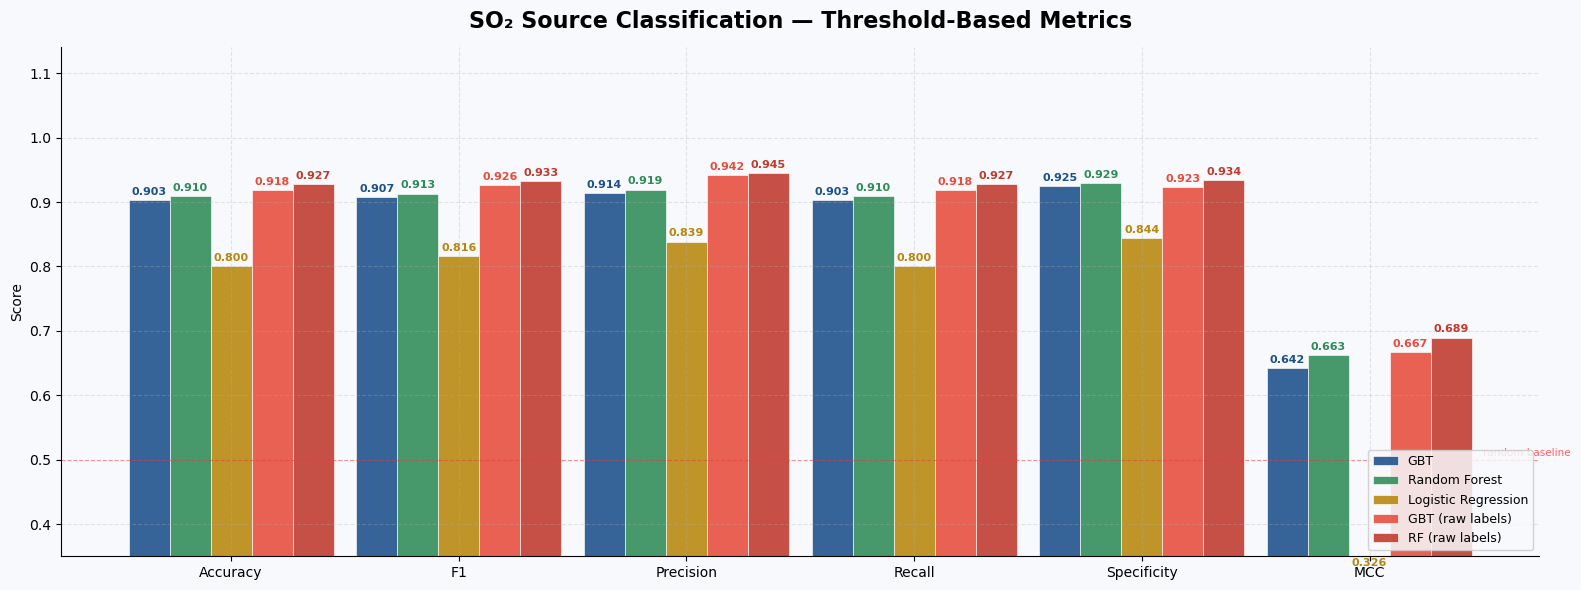

In [32]:
# Bar chart
bar_metrics = [
    ("accuracy",    "Accuracy"),
    ("f1",          "F1"),
    ("precision",   "Precision"),
    ("recall",      "Recall"),
    ("specificity", "Specificity"),
    ("mcc",         "MCC"),
]

n_metrics = len(bar_metrics)
n_models  = len(all_results)
x         = np.arange(n_metrics)
width     = 0.18
offsets   = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width
 
fig1, ax1 = plt.subplots(figsize=(16, 6))
fig1.patch.set_facecolor("#F7F9FC")
 
for i, (res, color, label) in enumerate(zip(all_results, colors, model_labels)):
    vals = [res[mk] for mk, _ in bar_metrics]
    bars = ax1.bar(x + offsets[i], vals, width,
                   label=label, color=color,
                   alpha=0.88, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8,
            color=color, fontweight="bold"
        )
 
ax1.set_xticks(x)
ax1.set_xticklabels([dl for _, dl in bar_metrics], fontsize=10)
ax1.set_ylim(0.35, 1.14)
ax1.set_ylabel("Score")
ax1.set_title("SO₂ Source Classification — Threshold-Based Metrics",
              fontweight="bold", pad=14, fontsize=16)
ax1.legend(loc="lower right", fontsize=9, framealpha=0.85)
ax1.axhline(0.5, color="red", lw=0.8, linestyle="--", alpha=0.35)
ax1.text(n_metrics - 0.5, 0.505, "random baseline",
         fontsize=7.5, color="red", alpha=0.6)
 
fig1.tight_layout()
plt.savefig("fig1_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

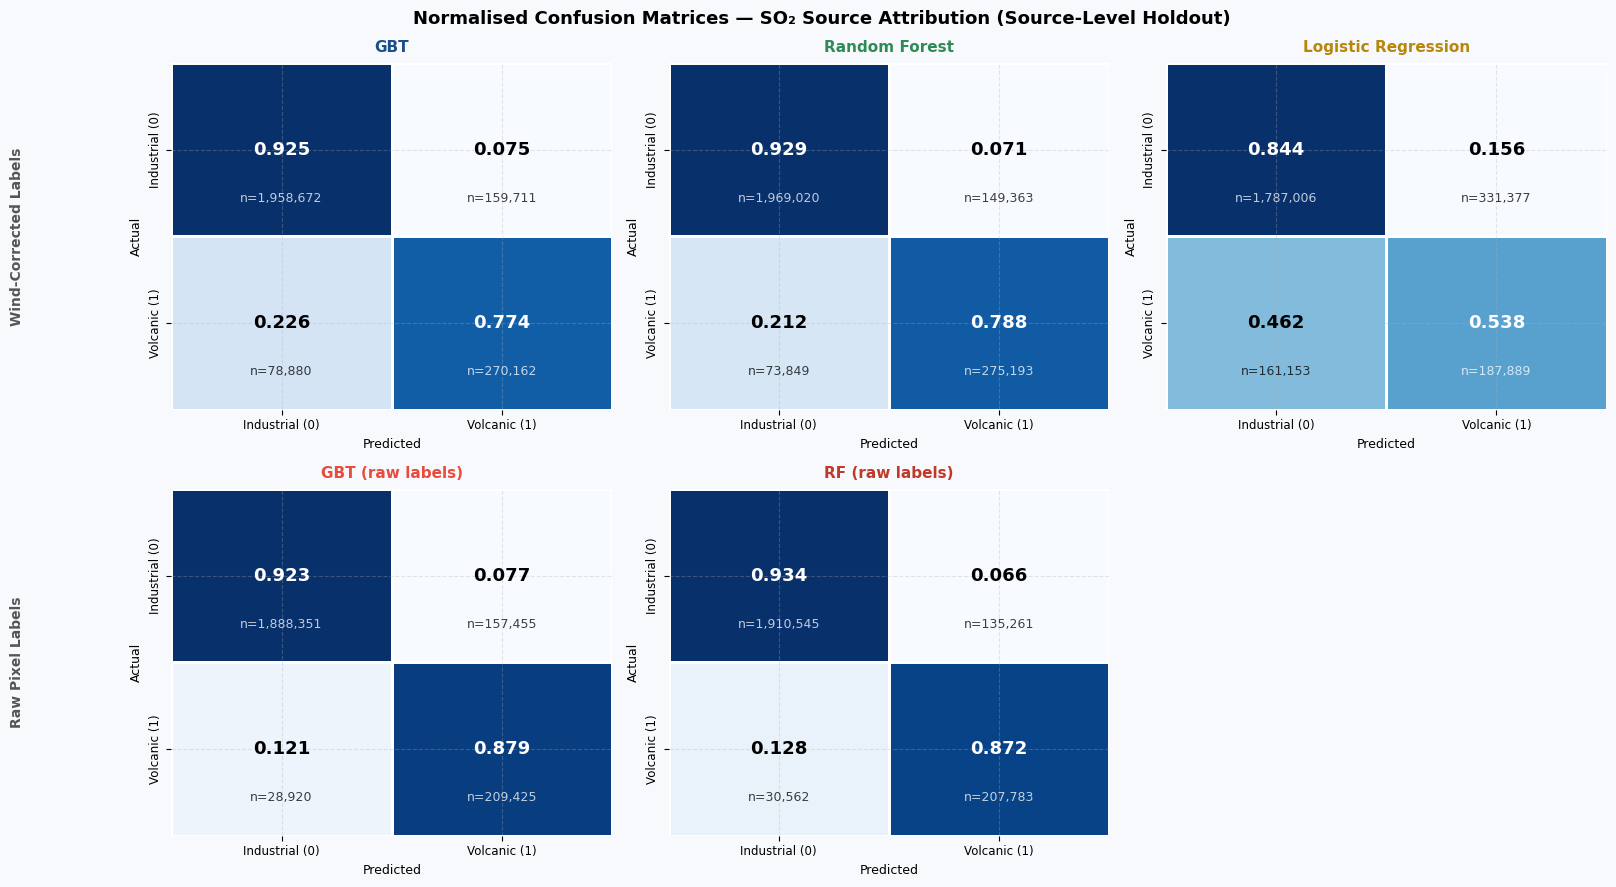

In [33]:
# Confusion Matrices Comparison
class_labels = ["Industrial (0)", "Volcanic (1)"]

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))
fig2.patch.set_facecolor("#F7F9FC")

primary   = [res_gbt, res_rf, res_lr]
secondary = [res_gbt_new, res_rf_new]

top_colors    = [PALETTE[r["model"]] for r in primary]
bottom_colors = [PALETTE[r["model"]] for r in secondary]

# Hide the third subplot in the second row
axes2[1, 2].set_visible(False)

for axes_group, results_group, colors_group in [
    (axes2[0, :],   primary,   top_colors),
    (axes2[1, :2],  secondary, bottom_colors),
]:
    for ax, res, color in zip(axes_group, results_group, colors_group):
        cm_raw  = np.array([[res["tn"], res["fp"]],
                            [res["fn"], res["tp"]]], dtype=float)
        cm_norm = cm_raw / cm_raw.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=True, fmt=".3f", ax=ax,
            cmap="Blues", cbar=False,
            xticklabels=class_labels,
            yticklabels=class_labels,
            linewidths=0.8, linecolor="white",
            annot_kws={"size": 13, "weight": "bold"},
        )
        for row_i in range(2):
            for col_j in range(2):
                val        = cm_norm[row_i, col_j]
                text_color = "white" if val > 0.5 else "black"
                ax.texts[row_i * 2 + col_j].set_color(text_color)
                ax.text(
                    col_j + 0.5, row_i + 0.78,
                    f"n={int(cm_raw[row_i, col_j]):,}",
                    ha="center", va="center",
                    fontsize=9, color=text_color, alpha=0.75
                )
        ax.set_title(DISPLAY[res["model"]],
                     fontsize=11, fontweight="bold", color=color, pad=8)
        ax.set_xlabel("Predicted", fontsize=9)
        ax.set_ylabel("Actual",    fontsize=9)
        ax.tick_params(labelsize=8.5)

axes2[0, 0].annotate(
    "Wind-Corrected Labels", xy=(-0.35, 0.5),
    xycoords="axes fraction", fontsize=10,
    fontweight="bold", color="#555555",
    ha="center", va="center", rotation=90,
)
axes2[1, 0].annotate(
    "Raw Pixel Labels", xy=(-0.35, 0.5),
    xycoords="axes fraction", fontsize=10,
    fontweight="bold", color="#555555",
    ha="center", va="center", rotation=90,
)

fig2.suptitle(
    "Normalised Confusion Matrices — SO₂ Source Attribution (Source-Level Holdout)",
    fontsize=13, fontweight="bold"
)
fig2.tight_layout()
plt.savefig("fig2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

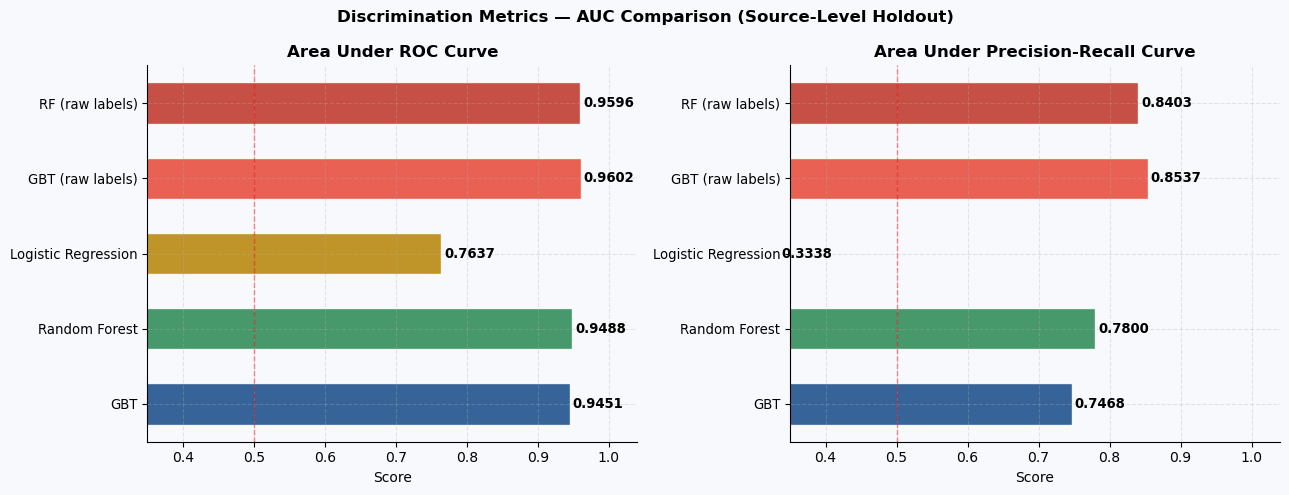

In [34]:
# AUC Comparison
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(13, 5))
fig3.patch.set_facecolor("#F7F9FC")

ml_results = [res_gbt, res_rf, res_lr, res_gbt_new, res_rf_new]
ml_labels  = [DISPLAY[r["model"]] for r in ml_results]
ml_colors  = [PALETTE[r["model"]] for r in ml_results]

for ax, metric_key, title in [
    (ax3a, "auc_roc", "Area Under ROC Curve"),
    (ax3b, "auc_pr",  "Area Under Precision-Recall Curve"),
]:
    vals = [r[metric_key] for r in ml_results]
    ypos = np.arange(len(ml_results))
    bars = ax.barh(ypos, vals, color=ml_colors,
                   alpha=0.88, edgecolor="white", height=0.55)
    ax.set_yticks(ypos)
    ax.set_yticklabels(ml_labels, fontsize=9.5)
    ax.set_xlim(0.35, 1.04)
    ax.set_xlabel("Score")
    ax.set_title(title, fontweight="bold")
    ax.axvline(0.5, color="red", lw=1, linestyle="--", alpha=0.45)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.004,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9.5, fontweight="bold")

fig3.suptitle("Discrimination Metrics — AUC Comparison (Source-Level Holdout)",
              fontsize=12, fontweight="bold")
fig3.tight_layout()
plt.savefig("fig3_auc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

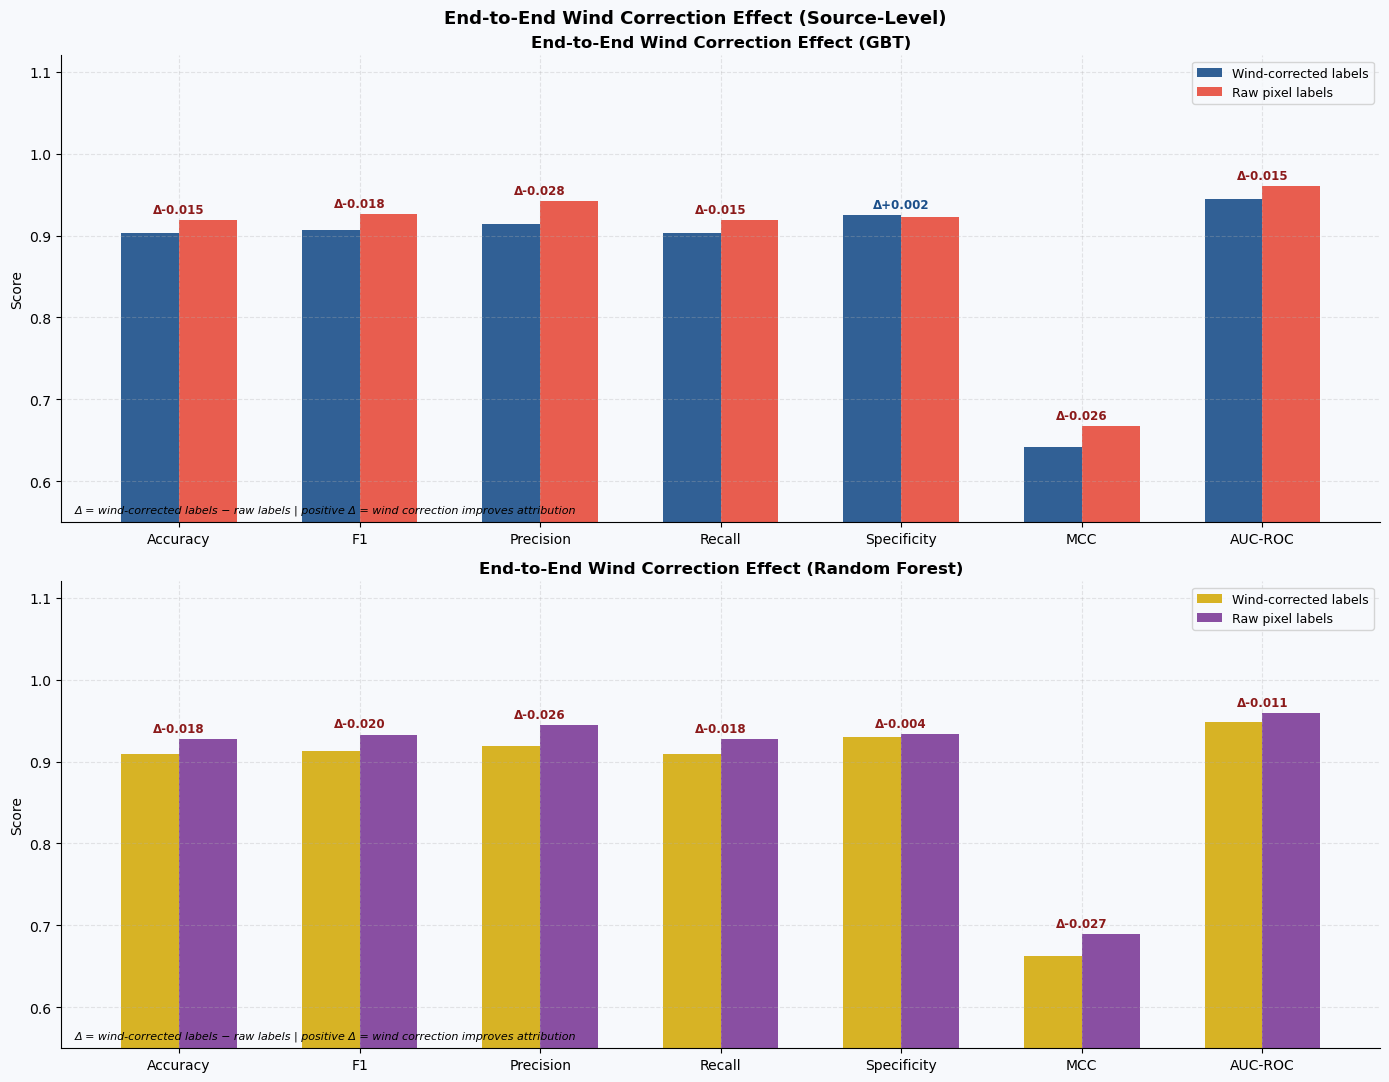

In [35]:
# The contribution of wind correction
abl_metrics = [
    ("accuracy",    "Accuracy"),
    ("f1",          "F1"),
    ("precision",   "Precision"),
    ("recall",      "Recall"),
    ("specificity", "Specificity"),
    ("mcc",         "MCC"),
    ("auc_roc",     "AUC-ROC"),
]

x4 = np.arange(len(abl_metrics))
w4 = 0.32

fig4, (ax4a, ax4b) = plt.subplots(2, 1, figsize=(14, 11))
fig4.patch.set_facecolor("#F7F9FC")

for ax, res_wind, res_raw, model_label, color_wind, color_raw in [
    (ax4a, res_gbt, res_gbt_new, "GBT",           "#1B4F8A", "#E74C3C"),
    (ax4b, res_rf,  res_rf_new,  "Random Forest",  "#D4AC0D", "#7D3C98"),
]:
    ax.bar(
        x4 - w4/2,
        [res_wind[mk] for mk, _ in abl_metrics],
        w4, label="Wind-corrected labels",
        color=color_wind, alpha=0.9
    )
    ax.bar(
        x4 + w4/2,
        [res_raw[mk] for mk, _ in abl_metrics],
        w4, label="Raw pixel labels",
        color=color_raw, alpha=0.9
    )
    for xi, (mk, _) in zip(x4, abl_metrics):
        delta = res_wind[mk] - res_raw[mk]
        top   = max(res_wind[mk], res_raw[mk]) + 0.005
        sign  = "+" if delta >= 0 else ""
        ax.annotate(
            f"Δ{sign}{delta:.3f}",
            xy=(xi, top), ha="center", va="bottom",
            fontsize=8.5, fontweight="bold",
            color="#1B4F8A" if delta >= 0 else "#8B1A1A"
        )
    ax.set_xticks(x4)
    ax.set_xticklabels([dl for _, dl in abl_metrics], fontsize=10)
    ax.set_ylim(0.55, 1.12)
    ax.set_ylabel("Score")
    ax.set_title(
        f"End-to-End Wind Correction Effect ({model_label})",
        fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.text(
        0.01, 0.02,
        "Δ = wind-corrected labels − raw labels | positive Δ = wind correction improves attribution",
        transform=ax.transAxes, fontsize=8, color="black", style="italic"
    )
fig4.suptitle(
    "End-to-End Wind Correction Effect (Source-Level)",
    fontsize=13, fontweight="bold"
)
fig4.tight_layout()
plt.savefig("fig4_wind_correction_endtoend.png", dpi=150, bbox_inches="tight")
plt.show()

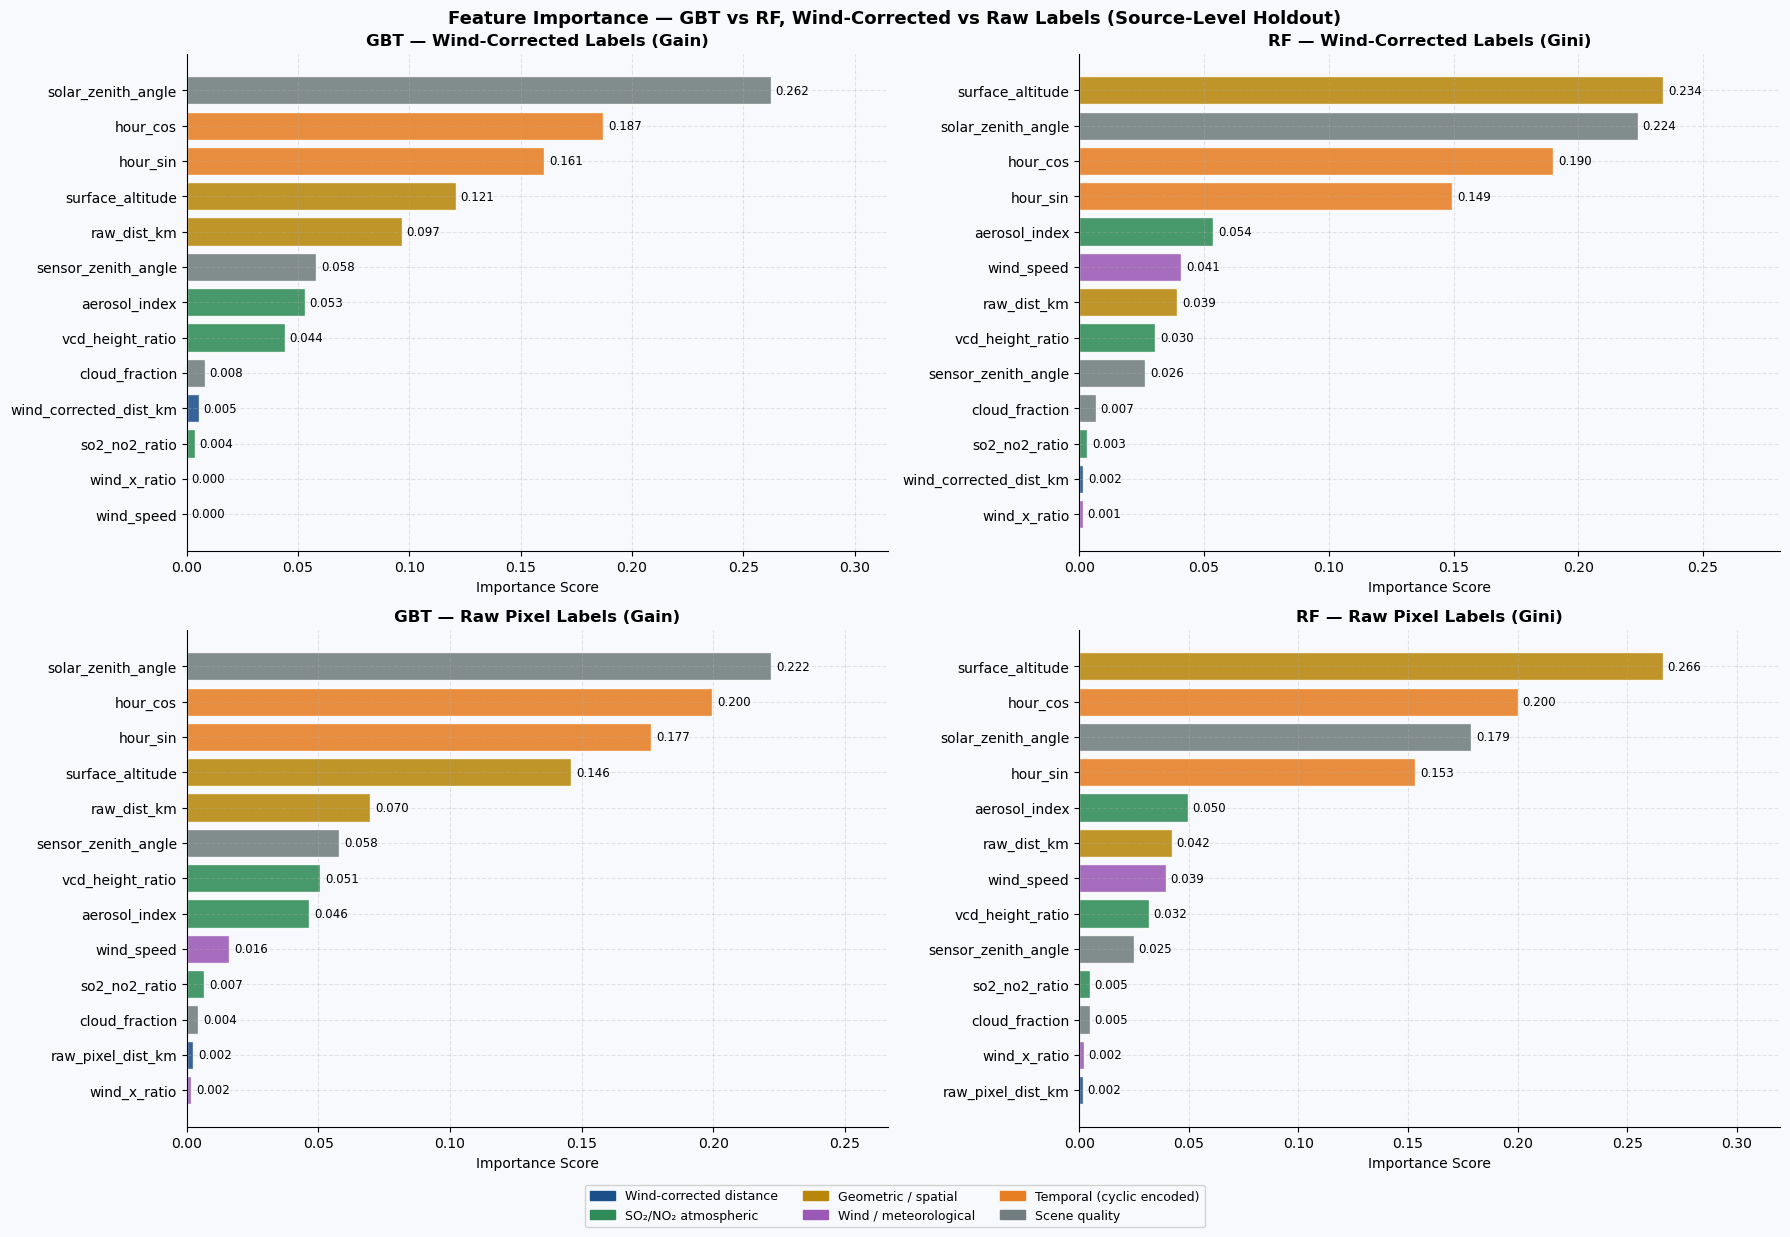

In [36]:
# Feature Importance Comparison
group_colors = {
    "wind_corrected_dist_km": "#1B4F8A",
    "raw_pixel_dist_km":      "#1B4F8A",
    "vcd_height_ratio":       "#2E8B57",
    "so2_no2_ratio":          "#2E8B57",
    "aerosol_index":          "#2E8B57",
    "raw_dist_km":            "#B8860B",
    "source_elevation_m":     "#B8860B",
    "surface_altitude":       "#B8860B",
    "wind_speed":             "#9B59B6",
    "wind_x_ratio":           "#9B59B6",
    "cloud_fraction":         "#717D7E",
    "solar_zenith_angle":     "#717D7E",
    "sensor_zenith_angle":    "#717D7E",
    "hour_sin":               "#E67E22",
    "hour_cos":               "#E67E22",
}
fig5, axes5 = plt.subplots(2, 2, figsize=(18, 12))
fig5.patch.set_facecolor("#F7F9FC")

# Extract feature importances for raw-labels models
fi_gbt_new = fitted_gbt_new.stages[-1].featureImportances
fi_gbt_new_dict = {
    all_features_new[i]: float(fi_gbt_new[i])
    for i in range(len(all_features_new))
}

fi_rf_new = fitted_rf_new.stages[-1].featureImportances
fi_rf_new_dict = {
    all_features_new[i]: float(fi_rf_new[i])
    for i in range(len(all_features_new))
}

plot_configs = [
    (axes5[0, 0], fi_gbt_dict,     "GBT — Wind-Corrected Labels (Gain)"),
    (axes5[0, 1], fi_rf_dict,      "RF — Wind-Corrected Labels (Gini)"),
    (axes5[1, 0], fi_gbt_new_dict, "GBT — Raw Pixel Labels (Gain)"),
    (axes5[1, 1], fi_rf_new_dict,  "RF — Raw Pixel Labels (Gini)"),
]

for ax, fi_dict, title in plot_configs:
    sorted_items = sorted(fi_dict.items(), key=lambda x: x[1])
    feats, imps  = zip(*sorted_items)
    bar_cols     = [group_colors.get(f, "#717D7E") for f in feats]

    bars = ax.barh(feats, imps, color=bar_cols, alpha=0.88, edgecolor="white")
    for bar, val in zip(bars, imps):
        ax.text(val + 0.002,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8.5)
    ax.set_xlabel("Importance Score")
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, max(imps) * 1.20)

legend_patches = [
    mpatches.Patch(color="#1B4F8A", label="Wind-corrected distance"),
    mpatches.Patch(color="#2E8B57", label="SO₂/NO₂ atmospheric"),
    mpatches.Patch(color="#B8860B", label="Geometric / spatial"),
    mpatches.Patch(color="#9B59B6", label="Wind / meteorological"),
    mpatches.Patch(color="#E67E22", label="Temporal (cyclic encoded)"),
    mpatches.Patch(color="#717D7E", label="Scene quality"),
]
fig5.legend(handles=legend_patches, loc="lower center",
            ncol=3, fontsize=9,
            bbox_to_anchor=(0.5, -0.04), framealpha=0.85)

fig5.suptitle(
    "Feature Importance — GBT vs RF, Wind-Corrected vs Raw Labels (Source-Level Holdout)",
    fontsize=13, fontweight="bold"
)
fig5.tight_layout()
plt.savefig("fig5_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# Save all the figs into the bucket
for fname in [
    "fig1_metrics_bar.png",
    "fig2_confusion_matrices.png",
    "fig3_auc_comparison.png",
    "fig4_wind_correction_endtoend.png",
    "fig5_feature_importance.png",
]:
    subprocess.run(["gsutil", "cp", fname, output_path + fname], capture_output=True)